# Yokogawa AQ637x — Quick Example

This example demonstrates the main usage patterns of the `YokogawaAQ637x` driver: connecting to the instrument, configuring measurement parameters, triggering a sweep, reading and plotting trace data, and capturing instrument state via snapshots.

**Note:** Replace the VISA resource string with your instrument address before running.


## 1) Imports and Connection


In [39]:
import json
import matplotlib.pyplot as plt
from qcodes_contrib_drivers.drivers.Yokogawa.Yokogawa_AQ637x import YokogawaAQ637x

# Connect to the instrument (replace address with your instrument's VISA resource string)
inst = YokogawaAQ637x("OSA", address="TCPIP::192.168.50.163::INSTR")

print("Connected to:", inst.get_idn())


Connected to: {'vendor': 'YOKOGAWA', 'model': 'AQ6370C', 'serial': '91MC06547', 'firmware': '04.06'}


## 2) Configure Measurement and Trigger a Sweep


In [40]:
# Configure measurement parameters
inst.sense_wavelength_start(1.0e-6)      # Start wavelength (m)
inst.sense_wavelength_stop(1.7e-6)       # Stop wavelength (m)
inst.sense_bandwidth_resolution(1e-9)    # Resolution bandwidth (m)
inst.sense_sensitivity('NORMAL_AUTO')    # Sensitivity mode

# Select active trace and perform a single sweep
inst.TRA.active()
inst.single()

print("Sweep complete.")


Sweep complete.


## 3) Read and Plot Trace Data


Data points: 5501
Wavelength range: 600.00 nm to 1700.00 nm


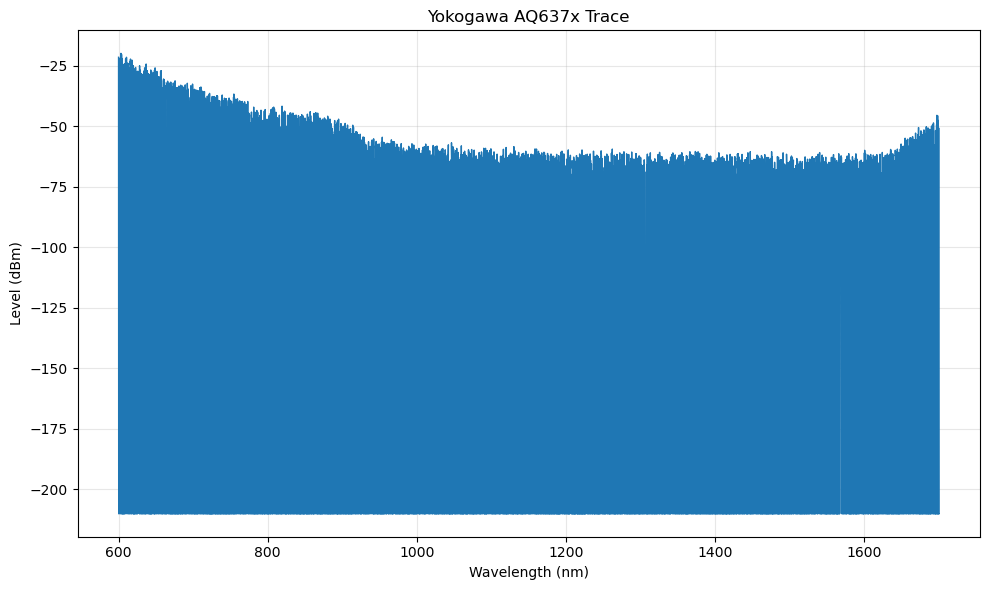

In [41]:
# Retrieve trace data
wavelengths = inst.TRA.data_x()  # Wavelengths in metres
levels = inst.TRA.data_y()       # Level data (typically dBm)

print(f"Data points: {len(wavelengths)}")
print(f"Wavelength range: {1e9 * wavelengths[0]:.2f} nm to {1e9 * wavelengths[-1]:.2f} nm")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(1e9 * wavelengths, levels, linewidth=1)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Level (dBm)')
plt.title('Yokogawa AQ637x Trace')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4) Capture Instrument State via Snapshot

Use QCoDeS snapshot feature to capture the current state of all instrument parameters. This is useful for documentation and reproducibility of measurements.


In [42]:
# Take a snapshot of the instrument state
snapshot = inst.snapshot(update=True)

# Display snapshot in human-readable format
inst.print_readable_snapshot()

# Optionally, save the full snapshot to a JSON file for later reference
with open("instrument_snapshot.json", "w") as f:
    json.dump(snapshot, f, indent=2, default=str)

print("\nFull snapshot saved to 'instrument_snapshot.json'")


[OSA(YokogawaAQ637x)] Snapshot: Could not update parameter: display_trace_y2_sminimum


OSA:
	parameter                        value
--------------------------------------------------------------------------------
IDN                               :	{'vendor': 'YOKOGAWA', 'model': 'AQ6370C'...
display_color                     :	1 
display_enabled                   :	True 
display_overview_position         :	RIGHT 
display_overview_size             :	LARGE 
display_split                     :	False 
display_split_hold_lower          :	False 
display_split_hold_upper          :	False 
display_text_data                 :	// AQ6370C OPTICAL SPECTRUM ANALYZER // 
display_trace_x_center            :	1.35e-06 (m)
display_trace_x_span              :	7e-07 (m)
display_trace_x_srange            :	True 
display_trace_x_start             :	1e-06 (m)
display_trace_x_stop              :	1.7e-06 (m)
display_trace_y1_blevel           :	0 (W)
display_trace_y1_pdivision        :	10 (dB)
display_trace_y1_rlevel           :	-10 (dBm)
display_trace_y1_rposition        :	8 (DIV)
display_trace

## 5) Cleanup



In [50]:
inst.close()
print("Connection closed.")

Connection closed.
